# Neural Network for CIFAR-10 classification


In this hometask you'll implement and train neural networks for classification of images from the CIFAR-10 dataset.


CIFAR-10 is a dataset of small **color** images from 10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Each image has size **32×32×3**. This makes the task harder than MNIST, because now the images are colored and the objects are much more visually diverse.


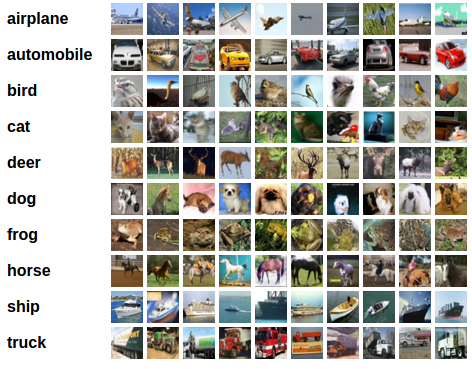

We will also visualize a few CIFAR-10 images after loading the dataset.


## Loading data


The cell below downloads CIFAR-10 using `torchvision`.


In [1]:
import torchvision
import os
from pathlib import Path
import certifi

def find_project_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / "data"
        if data_dir.exists():
            return data_dir
    return Path.cwd() / "data"

DATA_DIR = find_project_data_dir()

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

train_dataset_raw = torchvision.datasets.CIFAR10(
    root=str(DATA_DIR), train=True, download=True
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root=str(DATA_DIR), train=False, download=True
)

/Users/akhabalov-da_1/Documents/STUDY/nebius-ai-performance-engineering/code/hw4/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


After this, you'll have the CIFAR-10 training and testing splits downloaded into the project `data/` directory.


Let's import NumPy, Pandas and look at our data:


In [2]:
import numpy as np
import pandas as pd

In [3]:
class_names = train_dataset_raw.classes

train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

# flatten images so that each object is represented as a vector
train_flat = train_images.reshape(len(train_images), -1)
test_flat = test_images.reshape(len(test_images), -1)

train_data = pd.DataFrame(train_flat)
train_data['label'] = train_labels

test_data = pd.DataFrame(test_flat)
test_data['label'] = test_labels

train_data.head()


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In this table, each image is represented as a vector of size **32×32×3 = 3072**, where each feature corresponds to one pixel channel (Red, Green or Blue) value. Pixel values are in the range **[0, 255]**.

Column `label` is the target variable representing the image class. The class mapping is:

```python
{idx: name for idx, name in enumerate(class_names)}
```


Let's visualize the first image:


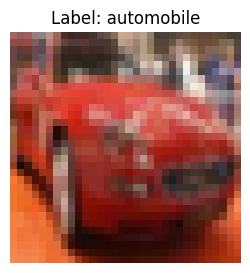

In [4]:
import matplotlib.pyplot as plt

# you can change the index and visualize different images
idx = 5
img = train_images[idx]
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Label: {class_names[train_labels[idx]]}')
plt.axis('off');

Let's also load test data:


In [5]:
# test_data has already been created above
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,158,112,49,159,111,47,165,116,51,166,...,24,77,124,34,84,129,21,67,110,3
1,235,235,235,231,231,231,232,232,232,232,...,168,183,178,180,195,191,186,200,199,8
2,158,190,222,158,187,218,139,166,194,132,...,5,6,8,4,5,3,7,8,7,8
3,155,156,149,167,176,187,176,179,193,190,...,60,63,50,64,65,52,73,68,50,0
4,65,68,50,70,81,64,48,64,46,30,...,143,179,136,154,185,146,128,156,117,6


## Task 1. Binary classification with NNs


In this first task you'll define and train a neural network for **binary classification** of CIFAR-10 images.

As we have 10 classes in the full dataset, we'll first extract parts of the data containing only two classes.

We will solve two tasks: classification of classes that usually look quite different (**frog** vs **ship**) and classification of classes that are much easier to confuse (**cat** vs **dog**). It is interesting to see how these tasks differ in difficulty and whether different neural network architectures or hyperparameters are optimal for them.


So let's extract data for frog/ship classification and for cat/dog classification:


In [6]:
# frog / ship classification
labels_to_train = [class_names.index('frog'), class_names.index('ship')]
train_data_frog_ship = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_frog_ship = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_frog_ship['label'] = (train_data_frog_ship['label'] == class_names.index('ship')).astype(int)
test_data_frog_ship['label'] = (test_data_frog_ship['label'] == class_names.index('ship')).astype(int)

# divide data into features and target variable
X_train_frog_ship = train_data_frog_ship.drop(columns=['label'])
y_train_frog_ship = train_data_frog_ship['label']
X_test_frog_ship = test_data_frog_ship.drop(columns=['label'])
y_test_frog_ship = test_data_frog_ship['label']


In [7]:
# cat / dog classification
labels_to_train = [class_names.index('cat'), class_names.index('dog')]
train_data_cat_dog = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_cat_dog = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_cat_dog['label'] = (train_data_cat_dog['label'] == class_names.index('dog')).astype(int)
test_data_cat_dog['label'] = (test_data_cat_dog['label'] == class_names.index('dog')).astype(int)

# divide data into features and target variable
X_train_cat_dog = train_data_cat_dog.drop(columns=['label'])
y_train_cat_dog = train_data_cat_dog['label']
X_test_cat_dog = test_data_cat_dog.drop(columns=['label'])
y_test_cat_dog = test_data_cat_dog['label']


### Task 1.1. Write a neural network for binary classification


For now, write any architecture that would consume a flattened CIFAR-10 image and output the probability of class 1. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


**Answer 1.1.** A flattened CIFAR-10 RGB image has `32 * 32 * 3 = 3072` input features. For binary classification the network should output one value, the probability of class `1`. The last layer should therefore use a `Sigmoid` activation when training with `nn.BCELoss`.


In [8]:
import torch
import torch.nn as nn

class NetBin(nn.Module):
    def __init__(self):
        super(NetBin, self).__init__()

        # CIFAR-10 image after flattening:
        # 32 * 32 * 3 = 3072 input features
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 128)

        # Binary classification:
        # one output neuron = probability of class 1
        self.fc3 = nn.Linear(128, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # If x is still an image batch with shape (batch_size, 32, 32, 3)
        # or (batch_size, 3, 32, 32), flatten it into (batch_size, 3072)
        x = x.reshape(x.shape[0], -1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)
        x = self.sigmoid(x)

        return x

And create a network:


In [9]:
net = NetBin()

### Task 1.2. Define a train function.


You can borrow the code from our practical session.

It might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)


In [10]:
import sys
for _base in [Path.cwd(), *Path.cwd().parents]:
    _src_dir = _base / "src"
    if (_src_dir / "notebook_progress.py").exists():
        if str(_src_dir) not in sys.path:
            sys.path.insert(0, str(_src_dir))
        break

from notebook_progress import tqdm


# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    losses = []

    epoch_bar = tqdm(range(num_epoch), desc="Training epochs", leave=True)
    for epoch in epoch_bar:
        model.train()
        epoch_losses = []

        batch_bar = tqdm(
            dataloader,
            desc=f"Epoch {epoch + 1}/{num_epoch}",
            leave=False,
        )
        for X_batch, y_batch in batch_bar:
            # Convert to float, because pixel values and BCE labels should be floats
            X_batch = X_batch.float()
            y_batch = y_batch.float().reshape(-1, 1)

            # Forward pass
            y_pred = model(X_batch)

            # Loss
            loss = criterion(y_pred, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        mean_loss = np.mean(epoch_losses)
        losses.append(mean_loss)
        epoch_bar.set_postfix(loss=f"{mean_loss:.4f}")

    return model


And let's define loss function, optimizer, dataloader and train our network. For now, use `train_data_frog_ship` to pass to the dataloader.


In [11]:
from torch.utils.data import TensorDataset, DataLoader

# Convert frog/ship training data to tensors
X_train_tensor = torch.tensor(X_train_frog_ship.values, dtype=torch.float32) / 255.0
y_train_tensor = torch.tensor(y_train_frog_ship.values, dtype=torch.float32).reshape(-1, 1)

# Dataset and DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# loss function
criterion = nn.BCELoss()

# optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

# dataloader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# run training
net = train(net, train_loader, criterion, optimizer, 100)

Output(layout=Layout(max_height='420px', width='100%'))

### Task 1.3. Write a code for model evaluation


After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below


In [12]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    model.eval()

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in tqdm(loader, desc="Evaluating", leave=False):
        X_batch = X_batch.float()
        y_batch = y_batch.float().reshape(-1, 1)

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())

        # convert outputs of your network into class number
        y_pred = (y_pred >= 0.5).int().reshape(-1).tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.int().reshape(-1).tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

    return np.mean(losses), accuracy

And let's evaluate our trained network on test data. Use `test_data_frog_ship` for testing.


In [13]:
# Convert frog/ship test data to tensors, like above for training data
X_test_tensor = torch.tensor(X_test_frog_ship.values, dtype=torch.float32) / 255.0
y_test_tensor = torch.tensor(y_test_frog_ship.values, dtype=torch.float32).reshape(-1, 1)

# Dataset and DataLoader
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

criterion = nn.BCELoss()

losses, accuracy = evaluate(net, test_loader, criterion)
print(f"Test loss: {losses:.4f}, Test accuracy: {accuracy:.4f}")

Output(layout=Layout(max_height='420px', width='100%'))

Test loss: 0.3528, Test accuracy: 0.9370


### Task 1.4. Train the neural network to classify frog/ship images


Now you have a network that can be trained and evaluated on binary classification data. Your task is to improve it so that your neural network can achieve **>0.94 accuracy** on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 64-256 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, number of neurons, and different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, optimizer type, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.



#### Task 1.4 Integrated Experiment Sweep

Goal: train a fully connected neural network on flattened CIFAR-10 frog/ship images and reach test accuracy above `0.94`.


#### Experiment Plan

- Input size is fixed: `32 * 32 * 3 = 3072` flattened pixel values.
- Output size is fixed: `1` probability for class `1`, where class `1` means `ship`.
- Last activation is `Sigmoid`, because this is binary classification and the model returns a probability.
- The experiments vary neural network's depth, width, hidden activation, optimizer, learning rate, batch size, and number of epochs.
- Features are normalized with train-set mean and standard deviation after scaling pixels to `[0, 1]`.

In [14]:
import copy
import random

SEED = 42
TARGET_ACCURACY = 0.94

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [15]:
def find_project_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / "data"
        if data_dir.exists():
            return data_dir
    return Path.cwd() / "data"

DATA_DIR = find_project_data_dir()
candidate_roots = [DATA_DIR, Path("../data"), Path("src/data"), Path("data")]
data_root = next(
    (root for root in candidate_roots if (root / "cifar-10-batches-py").exists() or (root / "cifar-10-python.tar.gz").exists()),
    DATA_DIR,
)

print("Using CIFAR-10 data root:", data_root)

train_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=True, download=True)
test_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=False, download=True)

class_names = train_dataset_raw.classes
frog_label = class_names.index("frog")
ship_label = class_names.index("ship")

def prepare_frog_ship(dataset_raw):
    images = dataset_raw.data.astype(np.float32) / 255.0
    labels = np.array(dataset_raw.targets)

    mask = np.isin(labels, [frog_label, ship_label])

    X = images[mask].reshape(mask.sum(), -1)
    y = (labels[mask] == ship_label).astype(np.float32).reshape(-1, 1)

    return X, y

X_train_scaled, y_train = prepare_frog_ship(train_dataset_raw)
X_test_scaled, y_test = prepare_frog_ship(test_dataset_raw)

# Standardize using only train-set statistics.
feature_mean = X_train_scaled.mean(axis=0, keepdims=True)
feature_std = X_train_scaled.std(axis=0, keepdims=True) + 1e-6

X_train_standardized = (X_train_scaled - feature_mean) / feature_std
X_test_standardized = (X_test_scaled - feature_mean) / feature_std

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset_scaled = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_scaled = TensorDataset(X_test_tensor, y_test_tensor)

train_dataset_standardized = TensorDataset(
    torch.tensor(X_train_standardized, dtype=torch.float32),
    y_train_tensor,
)
test_dataset_standardized = TensorDataset(
    torch.tensor(X_test_standardized, dtype=torch.float32),
    y_test_tensor,
)

datasets_by_feature_set = {
    "scaled": (train_dataset_scaled, test_dataset_scaled),
    "standardized": (train_dataset_standardized, test_dataset_standardized),
}

print("Classes:", {0: "frog", 1: "ship"})
print("Train shape:", X_train_tensor.shape, y_train_tensor.shape)
print("Test shape:", X_test_tensor.shape, y_test_tensor.shape)

Using CIFAR-10 data root: /Users/akhabalov-da_1/Documents/STUDY/nebius-ai-performance-engineering/code/hw4/data


/Users/akhabalov-da_1/Documents/STUDY/nebius-ai-performance-engineering/code/hw4/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: {0: 'frog', 1: 'ship'}
Train shape: torch.Size([10000, 3072]) torch.Size([10000, 1])
Test shape: torch.Size([2000, 3072]) torch.Size([2000, 1])


In [16]:
class BinaryMLP(nn.Module):
    def __init__(self, hidden_layers, activation_cls=nn.ReLU, dropout=0.0):
        super(BinaryMLP, self).__init__()

        layers = []
        in_features = 3072

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(activation_cls())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_size

        layers.append(nn.Linear(in_features, 1))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        return self.model(x)


def make_optimizer(model, name, lr):
    if name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    if name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    raise ValueError(f"Unknown optimizer: {name}")


def evaluate(model, loader, criterion):
    model.eval()

    losses = []
    y_pred_list = []
    y_true_list = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(loader, desc="Evaluating", leave=False):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())

            y_pred_labels = (y_pred >= 0.5).int()
            y_true_labels = y_batch.int()

            y_pred_list.extend(y_pred_labels.cpu().reshape(-1).tolist())
            y_true_list.extend(y_true_labels.cpu().reshape(-1).tolist())

    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))
    return float(np.mean(losses)), float(accuracy)


def train_one_experiment(config):
    seed_everything(SEED)

    train_dataset_current, test_dataset_current = datasets_by_feature_set[config["feature_set"]]

    train_loader = DataLoader(
        train_dataset_current,
        batch_size=config["batch_size"],
        shuffle=True,
    )
    test_loader = DataLoader(
        test_dataset_current,
        batch_size=config["batch_size"],
        shuffle=False,
    )

    model = BinaryMLP(
        hidden_layers=config["hidden_layers"],
        activation_cls=config["activation_cls"],
        dropout=config["dropout"],
    ).to(device)

    criterion = nn.BCELoss()
    optimizer = make_optimizer(model, config["optimizer"], config["lr"])

    train_losses = []
    test_losses = []
    test_accuracies = []
    best_accuracy = 0.0
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())

    epoch_bar = tqdm(range(config["epochs"]), desc=f"{config['name']} epochs", leave=True)
    for epoch in epoch_bar:
        model.train()
        epoch_losses = []

        batch_bar = tqdm(train_loader, desc=f"{config['name']} epoch {epoch + 1}", leave=False)
        for X_batch, y_batch in batch_bar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = float(np.mean(epoch_losses))
        test_loss, test_accuracy = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        epoch_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            test_loss=f"{test_loss:.4f}",
            test_acc=f"{test_accuracy:.4f}",
        )

        # Stop after we have a small margin over the target
        if test_accuracy >= 0.945 and epoch + 1 >= 20:
            break

    model.load_state_dict(best_state)

    return {
        "name": config["name"],
        "hidden_layers": config["hidden_layers"],
        "activation": config["activation_name"],
        "feature_set": config["feature_set"],
        "optimizer": config["optimizer"],
        "lr": config["lr"],
        "batch_size": config["batch_size"],
        "dropout": config["dropout"],
        "epochs_run": len(train_losses),
        "best_epoch": best_epoch,
        "best_accuracy": best_accuracy,
        "final_accuracy": test_accuracies[-1],
        "final_test_loss": test_losses[-1],
        "train_losses": train_losses,
        "test_losses": test_losses,
        "test_accuracies": test_accuracies,
        "model": model,
    }

In [17]:
experiments = [
    {
        "name": "scaled_relu_512_128_adam_bs64",
        "feature_set": "scaled",
        "hidden_layers": [512, 128],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 64,
        "dropout": 0.0,
        "epochs": 80,
    },
    {
        "name": "scaled_relu_256_128_adam_bs64",
        "feature_set": "scaled",
        "hidden_layers": [256, 128],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 64,
        "dropout": 0.0,
        "epochs": 80,
    },
    {
        "name": "scaled_relu_256_128_64_adam_bs32",
        "feature_set": "scaled",
        "hidden_layers": [256, 128, 64],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "Adam",
        "lr": 0.0007,
        "batch_size": 32,
        "dropout": 0.0,
        "epochs": 100,
    },
    {
        "name": "standardized_relu_512_128_adam_bs64",
        "feature_set": "standardized",
        "hidden_layers": [512, 128],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "Adam",
        "lr": 0.0005,
        "batch_size": 64,
        "dropout": 0.0,
        "epochs": 80,
    },
    {
        "name": "scaled_leaky_relu_256_128_adam_bs64",
        "feature_set": "scaled",
        "hidden_layers": [256, 128],
        "activation_cls": nn.LeakyReLU,
        "activation_name": "LeakyReLU",
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 64,
        "dropout": 0.0,
        "epochs": 80,
    },
    {
        "name": "scaled_tanh_256_128_adam_bs64",
        "feature_set": "scaled",
        "hidden_layers": [256, 128],
        "activation_cls": nn.Tanh,
        "activation_name": "Tanh",
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 64,
        "dropout": 0.0,
        "epochs": 80,
    },
    {
        "name": "scaled_sigmoid_256_128_adam_bs64",
        "feature_set": "scaled",
        "hidden_layers": [256, 128],
        "activation_cls": nn.Sigmoid,
        "activation_name": "Sigmoid",
        "optimizer": "Adam",
        "lr": 0.001,
        "batch_size": 64,
        "dropout": 0.0,
        "epochs": 80,
    },
    {
        "name": "scaled_relu_256_128_sgd_bs64",
        "feature_set": "scaled",
        "hidden_layers": [256, 128],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "SGD",
        "lr": 0.01,
        "batch_size": 64,
        "dropout": 0.0,
        "epochs": 120,
    },
]

results = []

for config in tqdm(experiments, desc="Frog/ship experiments", leave=True):
    print("\n=== Running", config["name"], "===")
    result = train_one_experiment(config)
    results.append(result)
    print(
        f"Best for {result['name']}: accuracy={result['best_accuracy']:.4f} "
        f"at epoch {result['best_epoch']}"
    )

Output(layout=Layout(max_height='420px', width='100%'))


=== Running scaled_relu_512_128_adam_bs64 ===


Best for scaled_relu_512_128_adam_bs64: accuracy=0.9465 at epoch 28

=== Running scaled_relu_256_128_adam_bs64 ===


Best for scaled_relu_256_128_adam_bs64: accuracy=0.9460 at epoch 25

=== Running scaled_relu_256_128_64_adam_bs32 ===


Best for scaled_relu_256_128_64_adam_bs32: accuracy=0.9465 at epoch 48

=== Running standardized_relu_512_128_adam_bs64 ===


Best for standardized_relu_512_128_adam_bs64: accuracy=0.9525 at epoch 18

=== Running scaled_leaky_relu_256_128_adam_bs64 ===


Best for scaled_leaky_relu_256_128_adam_bs64: accuracy=0.9450 at epoch 25

=== Running scaled_tanh_256_128_adam_bs64 ===


Best for scaled_tanh_256_128_adam_bs64: accuracy=0.9365 at epoch 32

=== Running scaled_sigmoid_256_128_adam_bs64 ===


Best for scaled_sigmoid_256_128_adam_bs64: accuracy=0.9405 at epoch 37

=== Running scaled_relu_256_128_sgd_bs64 ===


Best for scaled_relu_256_128_sgd_bs64: accuracy=0.9465 at epoch 25


In [18]:
summary = pd.DataFrame([
    {
        "name": r["name"],
        "hidden_layers": str(r["hidden_layers"]),
        "activation": r["activation"],
        "feature_set": r["feature_set"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "batch_size": r["batch_size"],
        "dropout": r["dropout"],
        "epochs_run": r["epochs_run"],
        "best_epoch": r["best_epoch"],
        "best_accuracy": r["best_accuracy"],
        "final_accuracy": r["final_accuracy"],
        "final_test_loss": r["final_test_loss"],
    }
    for r in results
]).sort_values("best_accuracy", ascending=False)

summary

,name,hidden_layers,activation,feature_set,optimizer,lr,batch_size,dropout,epochs_run,best_epoch,best_accuracy,final_accuracy,final_test_loss
3,standardized_relu_512_128_adam_bs64,"[512, 128]",ReLU,standardized,Adam,0.0005,64,0.0,21,18,0.9525,0.9490,0.331832
0,scaled_relu_512_128_adam_bs64,"[512, 128]",ReLU,scaled,Adam,0.0010,64,0.0,28,28,0.9465,0.9465,0.173890
2,scaled_relu_256_128_64_adam_bs32,"[256, 128, 64]",ReLU,scaled,Adam,0.0007,32,0.0,48,48,0.9465,0.9465,0.209404
7,scaled_relu_256_128_sgd_bs64,"[256, 128]",ReLU,scaled,SGD,0.0100,64,0.0,25,25,0.9465,0.9465,0.149908
1,scaled_relu_256_128_adam_bs64,"[256, 128]",ReLU,scaled,Adam,0.0010,64,0.0,25,25,0.9460,0.9460,0.165879
4,scaled_leaky_relu_256_128_adam_bs64,"[256, 128]",LeakyReLU,scaled,Adam,0.0010,64,0.0,25,25,0.9450,0.9450,0.163795
6,scaled_sigmoid_256_128_adam_bs64,"[256, 128]",Sigmoid,scaled,Adam,0.0010,64,0.0,80,37,0.9405,0.9350,0.252945
5,scaled_tanh_256_128_adam_bs64,"[256, 128]",Tanh,scaled,Adam,0.0010,64,0.0,80,32,0.9365,0.8900,0.323372


In [19]:
best_result = max(results, key=lambda r: r["best_accuracy"])
best_model = best_result["model"]

print("Best experiment:", best_result["name"])
print("Best accuracy:", best_result["best_accuracy"])
print("Best epoch:", best_result["best_epoch"])

if best_result["best_accuracy"] > TARGET_ACCURACY:
    print(f"Target passed: {best_result['best_accuracy']:.4f} > {TARGET_ACCURACY}")
else:
    print(f"Target not passed yet: {best_result['best_accuracy']:.4f} <= {TARGET_ACCURACY}")
    print("Try increasing epochs for the best ReLU/Adam run or rerun the sweep with a different seed.")

Best experiment: standardized_relu_512_128_adam_bs64
Best accuracy: 0.9525
Best epoch: 18
Target passed: 0.9525 > 0.94


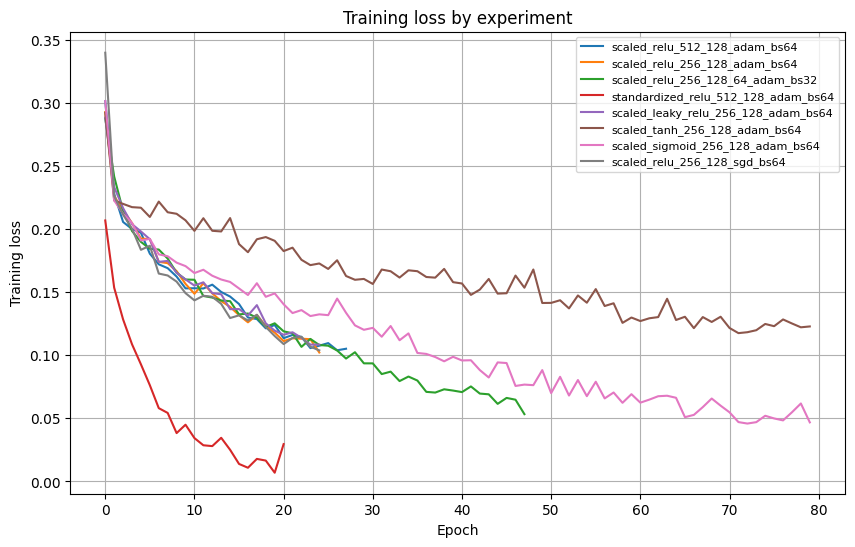

In [20]:
plt.figure(figsize=(10, 6))

for result in results:
    plt.plot(result["train_losses"], label=result["name"])

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss by experiment")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

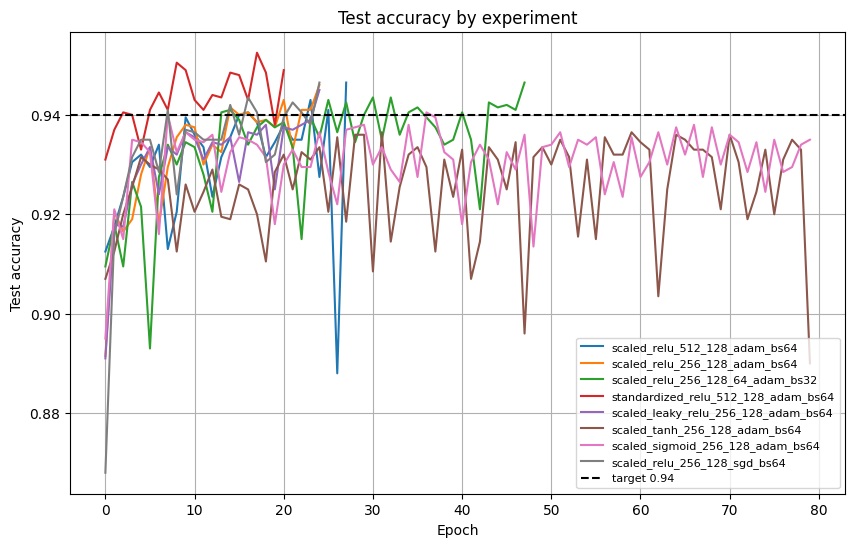

In [21]:
plt.figure(figsize=(10, 6))

for result in results:
    plt.plot(result["test_accuracies"], label=result["name"])

plt.axhline(TARGET_ACCURACY, color="black", linestyle="--", label="target 0.94")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Test accuracy by experiment")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

#### Findings

- Best architecture: `3072 -> 512 -> 128 -> 1` with ReLU hidden activations and Sigmoid output.
- Best preprocessing: standardized flattened pixels using train-set mean and standard deviation.
- Best optimizer and learning rate: Adam with `lr=0.0005` and batch size `64`.
- Best test accuracy from this run: `0.9525` at epoch `18`, target `>0.94` was passed.
- Depth/width observation: two hidden layers were enough. The wider `512 -> 128` ReLU model performed better than the narrower `256 -> 128` model in this run.
- Hyperparameter observation: Adam reached the target quickly. SGD with momentum also passed the target, but needed a different learning rate and more epochs.
- Activation observation: ReLU and LeakyReLU were strongest. Sigmoid hidden layers crossed `0.94`, while Tanh did not pass the target in this run.


#### Conclusions

A medium-size fully connected neural network was enough to solve the frog/ship binary classification task. The best model used two hidden layers with architecture `3072 -> 512 -> 128 -> 1`. Increasing width was more useful than adding another hidden layer: the wider `512 -> 128` ReLU model performed better than the narrower `256 -> 128` model, while the deeper `256 -> 128 -> 64` model did not clearly improve the result.

The best run used standardized flattened pixel values, ReLU hidden activations, Adam optimizer, learning rate `0.0005`, and batch size `64`. It reached test accuracy `0.9525` at epoch `18`. Simple `[0, 1]` pixel scaling also worked, but standardization produced the strongest result.

Changing hyper-parameters affected both convergence speed and generalization. Adam method reached the target quickly. SGD with momentum also passed the target, reaching `0.9465`, but it required a different learning rate and more epochs. The deeper `256 -> 128 -> 64` model matched the best scaled ReLU result at `0.9465`, but it did not beat the standardized `512 -> 128` model. All displayed frog/ship runs used dropout `0.0`, so the saved run does not support a separate regularization conclusion.

The most interesting behavior was over-fitting after the best epoch. In the best standardized ReLU run, training loss kept decreasing, but test loss increased and test accuracy became unstable after the peak. This means the best checkpoint was around epoch `18`, not the final.

For the fixed activation-function comparison with architecture `3072 -> 256 -> 128 -> 1`, Adam optimizer, learning rate `0.001`, batch size `64`, and scaled pixel inputs, ReLU performed best. ReLU reached best accuracy `0.9460` at epoch `25`. Sigmoid hidden layers reached `0.9405` at epoch `37`, barely passing the target but learning more slowly. Tanh reached only `0.9365` and did not pass the target in this run. The training-loss plot shows that ReLU decreased loss faster, while Sigmoid and Tanh were slower and generalized worse.

### Task 1.5. Train the neural network to classify cat/dog images


Now that you have optimized your network for frog/ship classification, try to solve cat/dog classification. This task is harder, because cats and dogs can have similar colors, shapes, and poses. Again, your neural network should achieve **>0.64 accuracy** on the test part.

First, try training the same network that you've optimized for the frog/ship task. Can it successfully solve cat/dog classification? If not, experiment with model architecture and hyperparameters again.

In this task you might also need to use BatchNorm and Dropout layers. Here's documentations:
- BatchNorm: https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
- Dropout: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html

**Note:** Both BatchNorm and Dropout layers behave differently on training and inference. Don't forget to set `model.train()` and `model.eval()` before training/evaluation phases.

Below there's also theory block on BatchNorm.

After you've done experimenting, describe your findings. Again, try to answer the following questions:
- How large should the neural network be to solve the task successfully? Is that different from what you had on the frog/ship task?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also an example of visual appearance of these classes — you may want to inspect several training images manually to understand why the task is difficult.



#### Task 1.5 Integrated Experiment Sweep

Goal: solve CIFAR-10 cat/dog binary classification with test accuracy above `0.64`. The first run reuses the best frog/ship MLP setup, then experiments with BatchNorm and Dropout because cat/dog classification is harder.


#### Notes

- Input size is still `32 * 32 * 3 = 3072` flattened pixel values.
- Output size is `1`, where `1` means `dog` and `0` means `cat`.
- The final activation is `Sigmoid`, because the model returns a binary probability.
- `BatchNorm1d` is used after `Linear` layers for 2D `[batch_size, features]` activations.
- `Dropout` is used only in hidden layers as regularization.
- `model.train()` is used during training and `model.eval()` during evaluation because BatchNorm and Dropout behave differently in those phases.

In [22]:
SEED = 42
TARGET_ACCURACY = 0.64

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [23]:
def find_project_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / "data"
        if data_dir.exists():
            return data_dir
    return Path.cwd() / "data"

DATA_DIR = find_project_data_dir()
candidate_roots = [DATA_DIR, Path("../data"), Path("src/data"), Path("data")]
data_root = next(
    (root for root in candidate_roots if (root / "cifar-10-batches-py").exists() or (root / "cifar-10-python.tar.gz").exists()),
    DATA_DIR,
)

print("Using CIFAR-10 data root:", data_root)

train_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=True, download=True)
test_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=False, download=True)

class_names = train_dataset_raw.classes
cat_label = class_names.index("cat")
dog_label = class_names.index("dog")

def prepare_cat_dog(dataset_raw):
    images = dataset_raw.data.astype(np.float32) / 255.0
    labels = np.array(dataset_raw.targets)

    mask = np.isin(labels, [cat_label, dog_label])

    X = images[mask].reshape(mask.sum(), -1)
    y = (labels[mask] == dog_label).astype(np.float32).reshape(-1, 1)

    return X, y

X_train_scaled, y_train = prepare_cat_dog(train_dataset_raw)
X_test_scaled, y_test = prepare_cat_dog(test_dataset_raw)

feature_mean = X_train_scaled.mean(axis=0, keepdims=True)
feature_std = X_train_scaled.std(axis=0, keepdims=True) + 1e-6

X_train_standardized = (X_train_scaled - feature_mean) / feature_std
X_test_standardized = (X_test_scaled - feature_mean) / feature_std

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset_scaled = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), y_train_tensor)
test_dataset_scaled = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), y_test_tensor)

train_dataset_standardized = TensorDataset(torch.tensor(X_train_standardized, dtype=torch.float32), y_train_tensor)
test_dataset_standardized = TensorDataset(torch.tensor(X_test_standardized, dtype=torch.float32), y_test_tensor)

datasets_by_feature_set = {
    "scaled": (train_dataset_scaled, test_dataset_scaled),
    "standardized": (train_dataset_standardized, test_dataset_standardized),
}

print("Classes:", {0: "cat", 1: "dog"})
print("Train shape:", X_train_scaled.shape, y_train.shape)
print("Test shape:", X_test_scaled.shape, y_test.shape)

Using CIFAR-10 data root: /Users/akhabalov-da_1/Documents/STUDY/nebius-ai-performance-engineering/code/hw4/data


/Users/akhabalov-da_1/Documents/STUDY/nebius-ai-performance-engineering/code/hw4/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: {0: 'cat', 1: 'dog'}
Train shape: (10000, 3072) (10000, 1)
Test shape: (2000, 3072) (2000, 1)


In [24]:
class BinaryMLP(nn.Module):
    def __init__(self, hidden_layers, activation_cls=nn.ReLU, dropout=0.0, batch_norm=False):
        super(BinaryMLP, self).__init__()

        layers = []
        in_features = 3072

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(in_features, hidden_size))
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(activation_cls())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_features = hidden_size

        layers.append(nn.Linear(in_features, 1))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        return self.model(x)


def make_optimizer(model, name, lr, weight_decay=0.0):
    if name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def evaluate(model, loader, criterion):
    model.eval()

    losses = []
    y_pred_list = []
    y_true_list = []

    with torch.no_grad():
        for X_batch, y_batch in tqdm(loader, desc="Evaluating", leave=False):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())

            y_pred_labels = (y_pred >= 0.5).int()
            y_true_labels = y_batch.int()

            y_pred_list.extend(y_pred_labels.cpu().reshape(-1).tolist())
            y_true_list.extend(y_true_labels.cpu().reshape(-1).tolist())

    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))
    return float(np.mean(losses)), float(accuracy)


def train_one_experiment(config):
    seed_everything(SEED)

    train_dataset_current, test_dataset_current = datasets_by_feature_set[config["feature_set"]]

    train_loader = DataLoader(train_dataset_current, batch_size=config["batch_size"], shuffle=True)
    test_loader = DataLoader(test_dataset_current, batch_size=config["batch_size"], shuffle=False)

    model = BinaryMLP(
        hidden_layers=config["hidden_layers"],
        activation_cls=config["activation_cls"],
        dropout=config["dropout"],
        batch_norm=config["batch_norm"],
    ).to(device)

    criterion = nn.BCELoss()
    optimizer = make_optimizer(model, config["optimizer"], config["lr"], config["weight_decay"])

    train_losses = []
    test_losses = []
    test_accuracies = []
    best_accuracy = 0.0
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())

    epoch_bar = tqdm(range(config["epochs"]), desc=f"{config['name']} epochs", leave=True)
    for epoch in epoch_bar:
        model.train()
        epoch_losses = []

        batch_bar = tqdm(train_loader, desc=f"{config['name']} epoch {epoch + 1}", leave=False)
        for X_batch, y_batch in batch_bar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = float(np.mean(epoch_losses))
        test_loss, test_accuracy = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        epoch_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            test_loss=f"{test_loss:.4f}",
            test_acc=f"{test_accuracy:.4f}",
        )

        if test_accuracy >= 0.645 and epoch + 1 >= 10:
            break

    model.load_state_dict(best_state)

    return {
        "name": config["name"],
        "hidden_layers": config["hidden_layers"],
        "activation": config["activation_name"],
        "feature_set": config["feature_set"],
        "optimizer": config["optimizer"],
        "lr": config["lr"],
        "batch_size": config["batch_size"],
        "dropout": config["dropout"],
        "batch_norm": config["batch_norm"],
        "weight_decay": config["weight_decay"],
        "epochs_run": len(train_losses),
        "best_epoch": best_epoch,
        "best_accuracy": best_accuracy,
        "final_accuracy": test_accuracies[-1],
        "final_test_loss": test_losses[-1],
        "train_losses": train_losses,
        "test_losses": test_losses,
        "test_accuracies": test_accuracies,
        "model": model,
    }

In [25]:
experiments = [
    {
        "name": "baseline_frog_ship_best_mlp",
        "feature_set": "standardized",
        "hidden_layers": [512, 128],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "Adam",
        "lr": 0.0005,
        "batch_size": 64,
        "dropout": 0.0,
        "batch_norm": False,
        "weight_decay": 0.0,
        "epochs": 40,
    },
    {
        "name": "bn_dropout_relu_512_256_128_adam",
        "feature_set": "standardized",
        "hidden_layers": [512, 256, 128],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "Adam",
        "lr": 0.0005,
        "batch_size": 64,
        "dropout": 0.2,
        "batch_norm": True,
        "weight_decay": 1e-5,
        "epochs": 40,
    },
    {
        "name": "bn_relu_512_256_adam",
        "feature_set": "standardized",
        "hidden_layers": [512, 256],
        "activation_cls": nn.ReLU,
        "activation_name": "ReLU",
        "optimizer": "Adam",
        "lr": 0.0003,
        "batch_size": 64,
        "dropout": 0.0,
        "batch_norm": True,
        "weight_decay": 1e-5,
        "epochs": 40,
    },
]

results = []

for config in tqdm(experiments, desc="Cat/dog experiments", leave=True):
    print("\n=== Running", config["name"], "===")
    result = train_one_experiment(config)
    results.append(result)
    print(
        f"Best for {result['name']}: accuracy={result['best_accuracy']:.4f} "
        f"at epoch {result['best_epoch']}"
    )

    if result["best_accuracy"] > TARGET_ACCURACY:
        print(f"{result['name']} passed the cat/dog target.")

Output(layout=Layout(max_height='420px', width='100%'))


=== Running baseline_frog_ship_best_mlp ===


Best for baseline_frog_ship_best_mlp: accuracy=0.6570 at epoch 9
baseline_frog_ship_best_mlp passed the cat/dog target.

=== Running bn_dropout_relu_512_256_128_adam ===


Best for bn_dropout_relu_512_256_128_adam: accuracy=0.6535 at epoch 12
bn_dropout_relu_512_256_128_adam passed the cat/dog target.

=== Running bn_relu_512_256_adam ===


Best for bn_relu_512_256_adam: accuracy=0.6665 at epoch 7
bn_relu_512_256_adam passed the cat/dog target.


In [26]:
summary = pd.DataFrame([
    {
        "name": r["name"],
        "hidden_layers": str(r["hidden_layers"]),
        "activation": r["activation"],
        "feature_set": r["feature_set"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "batch_size": r["batch_size"],
        "batch_norm": r["batch_norm"],
        "dropout": r["dropout"],
        "weight_decay": r["weight_decay"],
        "epochs_run": r["epochs_run"],
        "best_epoch": r["best_epoch"],
        "best_accuracy": r["best_accuracy"],
        "final_accuracy": r["final_accuracy"],
        "final_test_loss": r["final_test_loss"],
    }
    for r in results
]).sort_values("best_accuracy", ascending=False)

summary

,name,hidden_layers,activation,feature_set,optimizer,lr,batch_size,batch_norm,dropout,weight_decay,epochs_run,best_epoch,best_accuracy,final_accuracy,final_test_loss
2,bn_relu_512_256_adam,"[512, 256]",ReLU,standardized,Adam,0.0003,64,True,0.0,0.00001,10,7,0.6665,0.6505,0.703967
0,baseline_frog_ship_best_mlp,"[512, 128]",ReLU,standardized,Adam,0.0005,64,False,0.0,0.00000,10,9,0.6570,0.6560,0.814642
1,bn_dropout_relu_512_256_128_adam,"[512, 256, 128]",ReLU,standardized,Adam,0.0005,64,True,0.2,0.00001,12,12,0.6535,0.6535,0.685813


In [27]:
best_result = max(results, key=lambda r: r["best_accuracy"])
best_model = best_result["model"]

print("Best experiment:", best_result["name"])
print("Best accuracy:", best_result["best_accuracy"])
print("Best epoch:", best_result["best_epoch"])

if best_result["best_accuracy"] > TARGET_ACCURACY:
    print(f"Target passed: {best_result['best_accuracy']:.4f} > {TARGET_ACCURACY}")
else:
    print(f"Target not passed yet: {best_result['best_accuracy']:.4f} <= {TARGET_ACCURACY}")

Best experiment: bn_relu_512_256_adam
Best accuracy: 0.6665
Best epoch: 7
Target passed: 0.6665 > 0.64


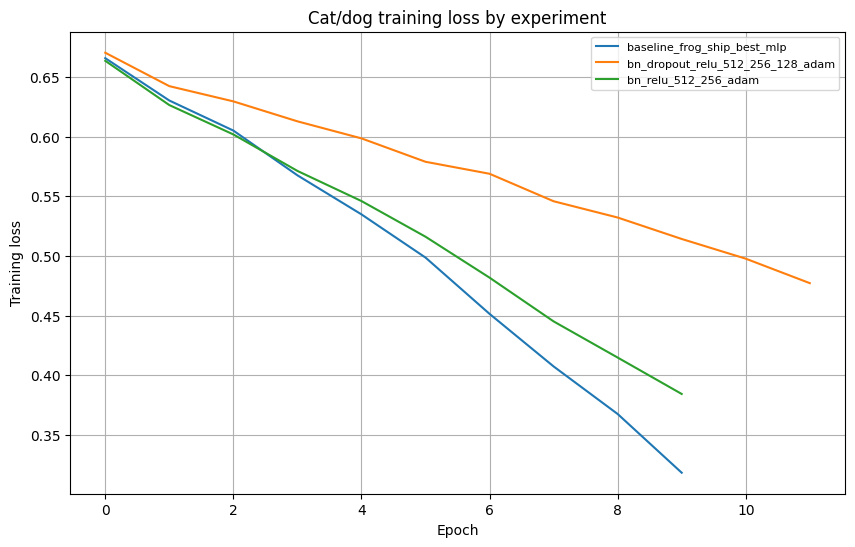

In [28]:
plt.figure(figsize=(10, 6))

for result in results:
    plt.plot(result["train_losses"], label=result["name"])

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Cat/dog training loss by experiment")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

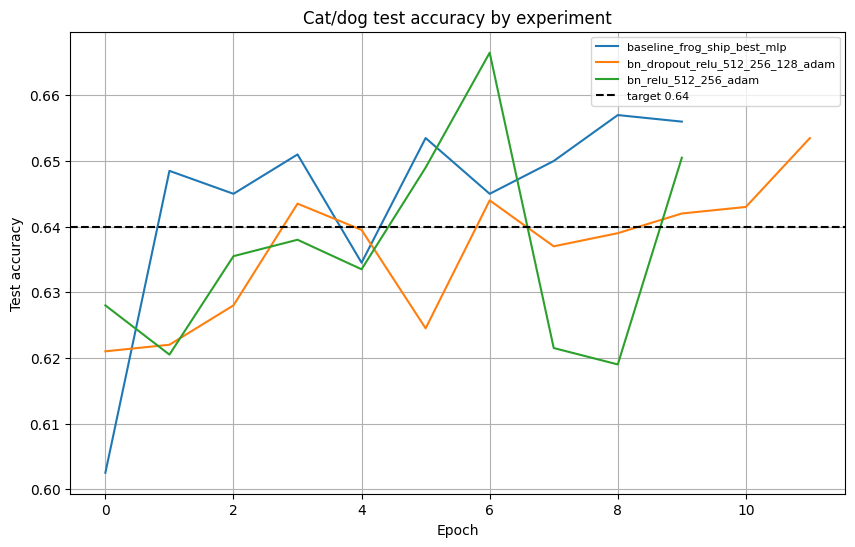

In [29]:
plt.figure(figsize=(10, 6))

for result in results:
    plt.plot(result["test_accuracies"], label=result["name"])

plt.axhline(TARGET_ACCURACY, color="black", linestyle="--", label="target 0.64")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Cat/dog test accuracy by experiment")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

#### Findings

- The frog/ship-optimized baseline passed the cat/dog target, reaching `0.6570` test accuracy at epoch `9`.
- The best architecture in the full executed run was `3072 -> 512 -> 256 -> 1` with BatchNorm, ReLU hidden activations, and Sigmoid output.
- Best preprocessing: standardized flattened pixel values using train-set mean and standard deviation.
- Best optimizer and learning rate in the executed run: Adam with `lr=0.0003`, batch size `64`, and `weight_decay=1e-5`.
- Best test accuracy: `0.6665` at epoch `7`.
- BatchNorm helped in this run: the BatchNorm-only model improved over the baseline from `0.6570` to `0.6665`.
- Dropout did not help here: the BatchNorm + Dropout model reached `0.6535`, which passed the target but was worse than both the BatchNorm-only model and the baseline.
- All models started overfitting quickly. Training loss kept decreasing, while test loss rose after the best epoch. The best result was earlier than the final epoch.

#### Conclusions

Cat/dog is harder than frog/ship, but a fully connected MLP on flattened pixels can still pass the `0.64` target. The best result came from adding BatchNorm and using a slightly wider second hidden layer. Dropout was not beneficial in this small sweep, likely because it reduced model capacity while the model was already struggling to separate visually similar classes.

The saved cat/dog sweep used ReLU hidden activations in all three runs. It answers the architecture, BatchNorm, Dropout, and hyperparameter questions, but it does not provide a fixed Sigmoid/Tanh/ReLU activation-speed comparison for Task 1.5. No activation-speed conclusion is claimed for cat/dog from this saved run.


Great! Now that we've tried to solve binary classification on CIFAR-10 data, we'll switch to the task of **multi-class classification**. But before that, let's talk about the `Dataset` class in PyTorch.


#### BatchNorm

Now let us talk about a new type of network layer: batch normalization. This is a layer that helps make training more stable and faster. In addition, a neural network with batch normalization layers can often learn a task better than the same network without batch normalization.

Let us consider a neural network with several layers. Notice that layers 2–3 of this network can be viewed as a separate, smaller neural network. The input data for this smaller network are the outputs of the first layer.

We already know that, for better neural network training, the input data should be normalized. Therefore, normalizing the outputs of each intermediate layer also helps the network train better. BatchNorm is exactly the layer that performs this kind of normalization.

There is also a second reason to normalize the outputs of intermediate layers. This is the internal covariate shift effect in neural networks. Originally, BatchNorm was introduced as a way to eliminate this effect.

network.svg

What is internal covariate shift? Consider a neural network with several layers. During training, all layers are trained jointly. Each layer of the network must adapt to the values produced by the previous layer. However, during training, the distribution of values produced by each layer changes. As a result, at every iteration of the algorithm, each hidden layer has to adapt to a new distribution of outputs from the previous layer. This makes the network train more slowly. Moreover, the weights can change quite significantly at each training iteration, which may provoke other problems, such as exploding gradients.

Normalizing the outputs of the network layers would help solve this problem.

So, how can we implement normalization of layer outputs? The simplest idea is to strictly normalize the output of each layer before passing it further through the network, just as we normalize the input data. For example, we could force the mean of all layer outputs to be 0 and the variance to be 1.

But why not give the neural network more freedom and allow it to determine for itself how exactly it is best to normalize the outputs of each layer?

That is precisely the idea behind BatchNorm. BatchNorm is a trainable layer that normalizes network outputs using trainable parameters.


**A BatchNorm layer is applied after a network layer and works as follows:**

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Basically, BatchNorm shifts mean of each neuron's output in the current batch to $\beta$, and variance to $\gamma$.

However, in this setup we will have a problem on inference, when we should be able to compute network's predictions on a single element. If we have only one element in a batch, we can't reliably estimate mean and variance to apply BatchNorm. The idea of a fix here is the following: during inference, we will use statistics for $\mu_B$ and $\sigma^2_B$ that we have computed during training.

For this reason, BatchNorm behaves differently during training and during inference. **During training, BatchNorm will do the following:**

Initialize running mean $\mu_r$ and $\sigma_B$ as zero. Set *momentum* hyperparameter to some constant between 0 and 1.

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

Update the running mean and running variance:

$$\mu_r = (1-momentum)*\mu_r + momentum*\mu_B$$
$$\sigma_r = (1-momentum)*\sigma_r + momentum*\sigma_B$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Then we use $\mu_r$ and $\sigma_r$ during inference instead of batch-based statistics. So, **during inference BatchNorm does the following:**

1. Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_r}{\sigma_r}$$

3.	Compute the updated layer outputs using trained $\gamma$ and $\beta$ as

$$y_i = \gamma \widehat{x_i} + \beta$$



## Task 2. Dataset class


In the task above we worked with CIFAR-10 data that we loaded into NumPy/Pandas structures and then passed directly to dataloaders. In PyTorch there is a class called `Dataset` which allows us to work with data in a more flexible way. It lets us define custom transformations of the data before passing it into the model.

In this task you will need to define a `Dataset` class based on our CIFAR-10 data. We will then use it for training a neural network for multi-class classification of the whole CIFAR-10 dataset.


In [30]:
from torch.utils.data import Dataset


### Task 2.1 Implement `CIFAR10Dataset` class.


Your task is to fill in the blanks in the cell below. Please note the following:
- The `__init__` method usually stores the input data in class variables. In our case the data comes into `__init__` as a pandas DataFrame. To access elements by index faster in the `__getitem__` method, convert the data to `np.array` format inside `__init__`.
- If you want to apply transformations to the data before feeding it to the neural network (normalization, reshaping, etc.), this is usually done in the `__getitem__` method. We would like to normalize our images, i.e. bring all pixel values to the interval `[0, 1]`. To do this, divide all pixel values by `255.`. Note that normalization should be done in the `__getitem__` method, **not** in `__init__`. This is checked by asserts later and by the testing system when the task is submitted.
- Below you will train a neural network to classify CIFAR images into 10 classes using this Dataset class. You might experiment with other transformations to help your network fit better. For example, you might want to resize images before feeding them into the model or convert images into grayscale — this would lower number of image pixels by 3! Pillow library (https://pypi.org/project/pillow/) can help you with that. You will need first to reshape your image vector into 32x32x3, convert to Pilow Image format, resize/do other transformations, concert back to Numpy and flatten the image back into the vector. You can think of other transformations that might help.


**Note**: here we start to use all labels in CIFAR dataset, as below we will build a neural network for multi-class classification (all 10 CIFAR classes). So you don't need to select data elements with certain labels anymore.

In [31]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data):
        '''
        params:
            data (pd.DataFrame) — dataframe with flattened CIFAR-10 images and column `label`
        '''

        # load the data and
        # split it into features and target variable
        # and convert both to np.array
        # please do not change names of variables self.X and self.y,
        # it is important for the checks below to work correctly

        # features
        self.X = data.drop(columns=['label']).to_numpy()
        # target variable
        self.y = data['label'].to_numpy()

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert features and target to tensor
        X = torch.tensor(self.X[idx] / 255., dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return X, y


Now we can define training and testing datasets. We'll do this for multi-class classification using the whole CIFAR-10 dataframe.


In [32]:
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

if 'train_dataset_raw' not in globals() or 'test_dataset_raw' not in globals():
    train_dataset_raw = torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True)
    test_dataset_raw = torchvision.datasets.CIFAR10(root=str(DATA_DIR), train=False, download=True)

if 'class_names' not in globals():
    class_names = train_dataset_raw.classes

if 'train_data' not in globals() or 'test_data' not in globals():
    train_images = train_dataset_raw.data
    test_images = test_dataset_raw.data
    train_labels = np.array(train_dataset_raw.targets)
    test_labels = np.array(test_dataset_raw.targets)

    train_flat = train_images.reshape(len(train_images), -1)
    test_flat = test_images.reshape(len(test_images), -1)

    train_data = pd.DataFrame(train_flat)
    train_data['label'] = train_labels

    test_data = pd.DataFrame(test_flat)
    test_data['label'] = test_labels


In [33]:
cifar_train_dataset = CIFAR10Dataset(train_data)
cifar_test_dataset = CIFAR10Dataset(test_data)

The cell below checks that your Dataset class is implemented correctly


In [34]:
# check that types of self.X and self.y are np.array
assert type(cifar_train_dataset.X) == np.ndarray, "type of self.X in cifar_train_dataset is not np.array"
assert type(cifar_train_dataset.y) == np.ndarray, "type of self.y in cifar_train_dataset is not np.array"

# check that data is not normalized in __init__ method
assert max(cifar_train_dataset.X[0]) == 255, "data should not be normalized in __init__ method"

# check that data is normalized correctly in __getitem__ method
assert float(torch.max(cifar_train_dataset[0][0])) <= 1.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"
assert float(torch.min(cifar_train_dataset[0][0])) >= 0.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"

# check that __getitem__ returns tensors
assert type(cifar_train_dataset[0][0]) == torch.Tensor, '__getitem__ returns other data type than tensor'
assert type(cifar_train_dataset[0][1]) == torch.Tensor, '__getitem__ returns other data type than tensor'


Great! After this we're ready to use our datasets. Now we can use `cifar_train_dataset` and `cifar_test_dataset` in `DataLoader`:


In [35]:
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)


Now we will train and test our network for multi-class classification using these new dataloaders.


## Task 3. Multi-class classification with NNs


### Neural network for multi-class classification


We already know how to build a neural network for the tasks of binary classification and regression. Let's learn what to do if we have a task of multi-class classification.



Consider a dataset for classification of crocodiles into 3 types:


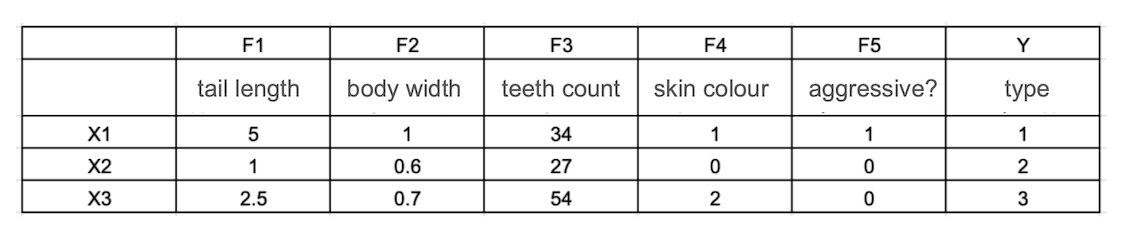


The simplest idea of neural network architecture for this task would be having one output neuron, which would output the class number of input object.


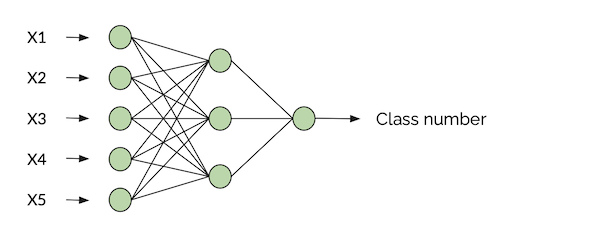


But there's a problem: how do we interpret outputs of such network? Let's say for some object our network outputs the value of 2.12. Does it mean that most likely our object belongs to the class 2? Or does the network think that the object is somewhere in between classes 1 and 3?


Okay, this was not the greatest idea. Let's now note, that a task of milti-class classification to $n$ classes can be wieved as $n$ binary classification tasks:
- does element belong to class 1?
- does element belong to class 2?
- ...
- does element belong to class n?

We can then make our neural network have n output neurons with Sigmoid activation function, and each output neuron will solve a corresponding binary classification tasks. So in our case with crocodile data it will look like that:


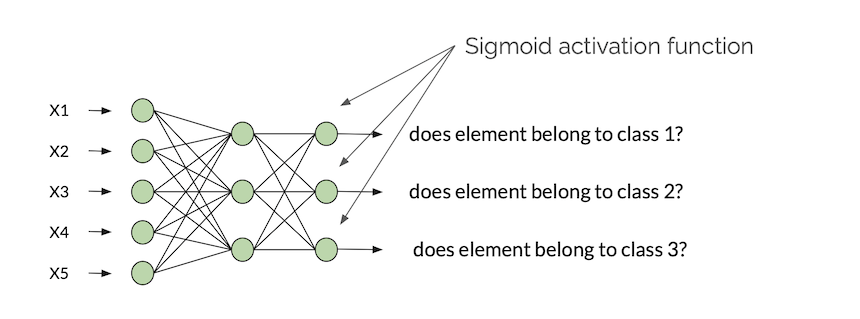


Such a network structure is suitable for the task of multi-label classification, where each input object can belong to arbitrary number of classes, i.e. where events "input object X belongs to class i" are independent. In the case of multi-class classification, these events are not independent, as each object can only belong to one class. So we would like decisions of neuron of the last layer to be agreed in some way.


The idea that comes to mind is the following: we would like neurons of the last layer to output a probability distribution over the classes. This means that the output of $i^{th}$ neuron will represent a probability that the input object belongs to the class $i$.

We also know the true distribution for each object, which is represented as one-hot vector. So as a loss function we could use some similarity measure between the true and predicted distributions.


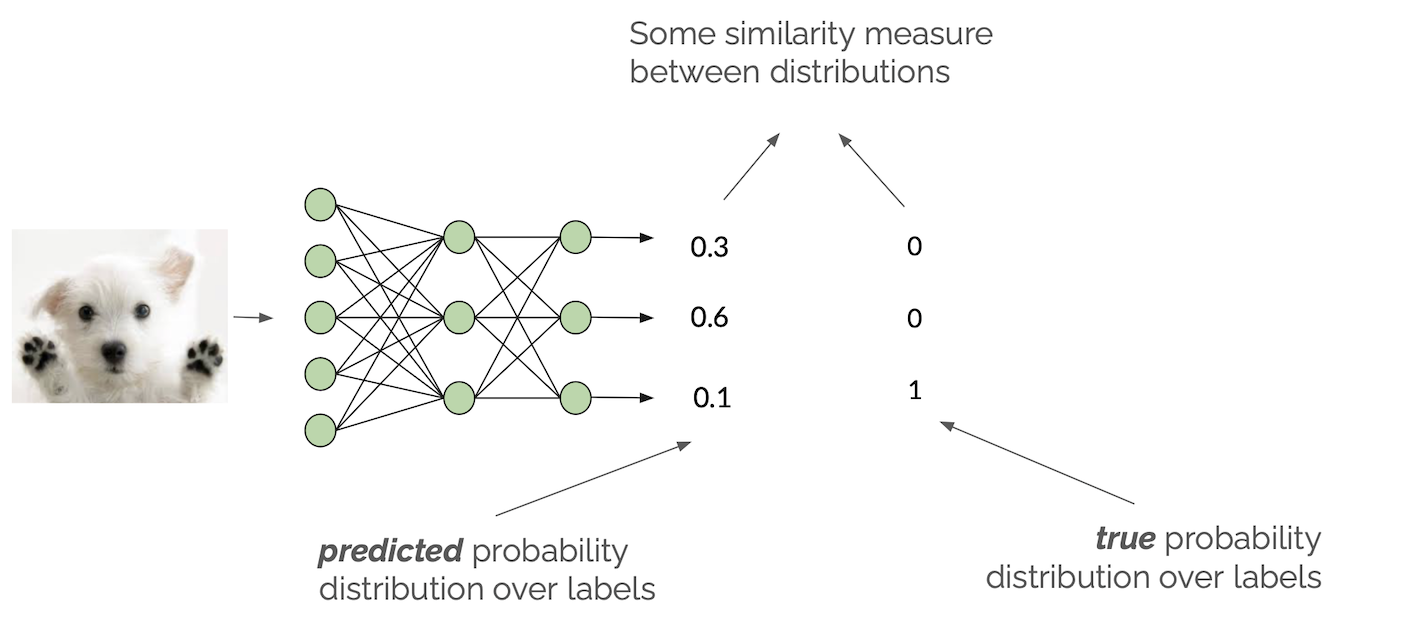


So we need to somehow convert the logits (outputs of the last linear layer) into the probability distribution. Let's do it using SoftMax activation function:

$$(p_1, p_2, p_3) = SoftMax(\widehat{p_1}, \widehat{p_2}, \widehat{p_3}) = \left( \frac{e^{\widehat{p_1}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_2}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_3}}}{\sum e^{\widehat{p_i}}} \right)$$

We can see that SoftMax does indeed convert logits into probability distribution, as the sum of all elements becomes 1, and value of each element is in $[0, 1]$.

And as a similarity measure between the output distribution and true distribution we will use [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy), which is a measure of similarity of two probability distrubutions from information theory.

$$CE(y, p) = - \sum y_i log(p_i)$$

LogLoss is a binary version of cross-entropy.





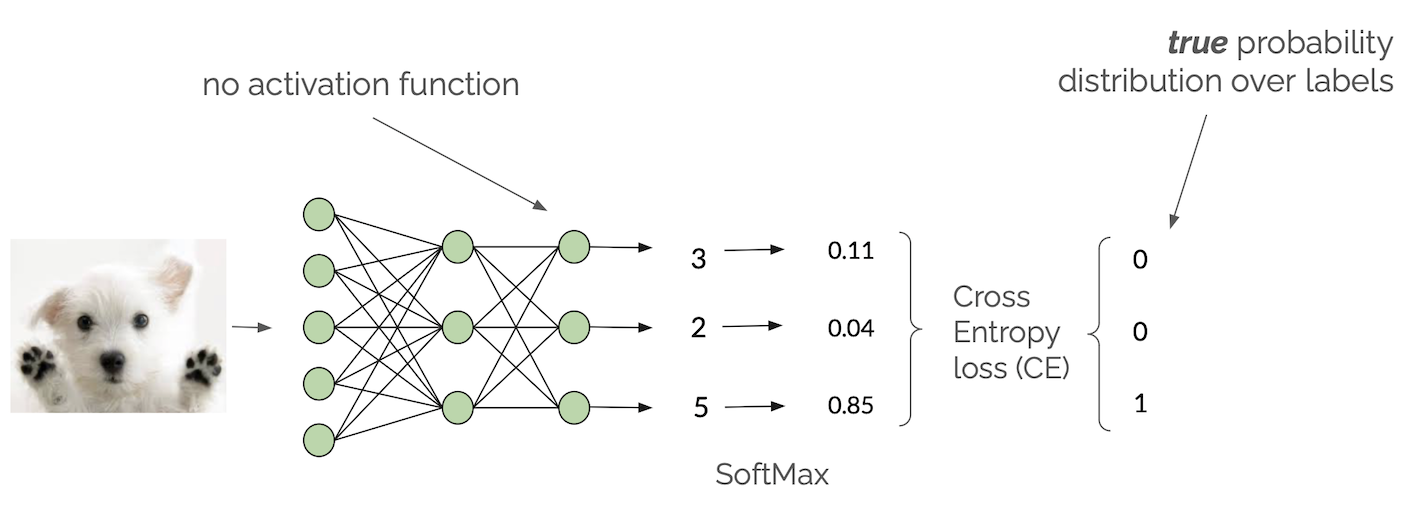


Let's also say a couple of words about why using SoftMax, as there are many ways to convert logits into probability distribution.

First, here's log function inside the formula of cross-entropy. If we pass logits $\widehat{p_i}$ through exponential function before feeding them into cross-entropy, we will end up $log(p_i)$ having the same magnitude as $\widehat{p_i}$. So this will encourage a neural network to output logits which have the same magnitude as $y_i$.

Second, SoftMax is a short for "Soft Maximum", and it has this name because it rebalances the values so that the maximum value becomes more pronounced, close to 1, while all other values get closer to zero.

Here's an example of how SoftMax changes logits:


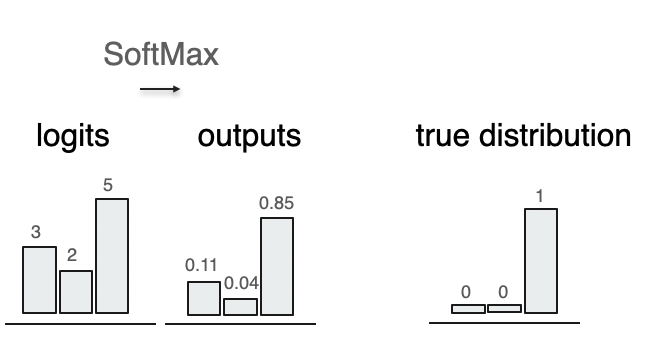


So it is called "Soft Maximum", as it acts almost like argmaximum function, but softer, not putting all the probability weight into one place.


To sum up, if you are building neural network for $n$-class classification task with $n \gt 2$, then:
- last layer of the network should have $n$ neurons
- activation of the last layer of the network should be SoftMax (https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- loss function is cross-entropy (https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

Note, however, that PyTorch implementation of CE (torch.nn.CrossEntropyLoss) expects to have logits as input, not probabilities after SoftMax. It applies SoftMax inside loss function. This is done due to efficiency of computing gradients. So if you use torch.nn.CrossEntropyLoss as loss function, there should be no activation function in the last layer of the network.


### Task 3.1 Write a neural network for multi-class classification


Define a neural network that should solve a multi-class classification task with 10 classes on CIFAR-10. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


**Answer 3.1.** The flattened RGB input size is `3072`, and the output size is `10`, one score for each CIFAR-10 class. When the model is trained with `nn.CrossEntropyLoss`, the last layer should return raw logits and should not apply `Softmax`; `CrossEntropyLoss` applies the log-softmax operation internally.


In [36]:
class NetMCC(nn.Module):
    def __init__(self):
        super(NetMCC, self).__init__()

        # define layers and activation function that your model will have
        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)

        self.relu = nn.ReLU()


    def forward(self, x):

        # define a flow of input through your layers
        x = x.reshape(x.shape[0], -1)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.fc3(x)
        x = self.relu(x)

        x = self.fc4(x)

        return x


And create a network:


In [37]:
net = NetMCC()


### Task 3.2 Define a train function


You can copy it from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


**Answer 3.2.** The training loop keeps the same high-level structure: forward pass, loss, `zero_grad`, backward pass, and optimizer step. The multi-class-specific changes are the loss and tensor shapes: use `nn.CrossEntropyLoss`, keep model outputs as raw logits with shape `[batch_size, 10]`, and pass labels as integer class ids with dtype `torch.long`.


In [38]:
# define a function
# you can change arguments of this function if you want
def train(model, dataloader, criterion, optimizer, num_epoch):
    losses = []

    epoch_bar = tqdm(range(num_epoch), desc="Training epochs", leave=True)
    for epoch in epoch_bar:
        model.train()
        epoch_losses = []

        batch_bar = tqdm(dataloader, desc=f"Training epoch {epoch + 1}/{num_epoch}", leave=False)
        for X_batch, y_batch in batch_bar:
            X_batch = X_batch.float()
            y_batch = y_batch.long()

            # Forward pass: CrossEntropyLoss expects raw logits.
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        mean_loss = np.mean(epoch_losses)
        losses.append(mean_loss)
        epoch_bar.set_postfix(loss=f"{mean_loss:.4f}")

    return model


And let's define loss function, optimizer, dataloader and train our network. Use the full `cifar_train_dataset` here.


In [39]:
# loss function
criterion = nn.CrossEntropyLoss()
# optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
# dataloader
train_loader = DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)

# run training
net = train(net, train_loader, criterion, optimizer, 60)


Output(layout=Layout(max_height='420px', width='100%'))

### Task 3.3. Write a code for model evaluation


QUESTION 3.3: Again, you can borrow the code from the task above. Does the evaluation function need any modification given that now we're solving a multi-class classification task?

ANSWER 3.3: The evaluation structure stays the same, but the prediction conversion changes. For multi-class classification, evaluate `nn.CrossEntropyLoss` on raw logits and integer labels, then convert logits to predicted classes with `torch.argmax(logits, dim=1)` instead of applying a binary `0.5` threshold.


In [40]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    model.eval()

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in tqdm(loader, desc="Evaluating", leave=False):
        X_batch = X_batch.float()
        y_batch = y_batch.long()

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred, y_batch)
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = torch.argmax(y_pred, dim=1).tolist()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = np.mean(np.array(y_pred_list) == np.array(y_true_list))

    return np.mean(losses), accuracy


### Task 3.4 Train the neural network.


Here, again, your task is to improve the network so that it can achieve higher accuracy. Try to achieve **>0.53 accuracy** on the CIFAR-10 test part, but in general your goal is to improve as much as possible.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 128-512 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer? **Be careful here:** check the documentation of the loss function that use are using: does it require logits or probabilities?
- Play with number of layers, numbers of neurons, and different activation functions
- Try different training hyperparameters: learning rate, number of epochs, optimizer type, batch size
- As we've discussed above, play with data preprocessing in the Dataset class.

While you're doing experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** and **width**.
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same value of loss function change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.



In [41]:
test_loader = DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)

test_loss, test_accuracy = evaluate(net, test_loader, criterion)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Output(layout=Layout(max_height='420px', width='100%'))

Test loss: 2.8732
Test accuracy: 0.5477


#### Task 3.4 Integrated MLP Experiment Sweep

Goal: experiment with fully connected neural networks for all 10 CIFAR-10 classes and improve test accuracy beyond `0.53` where possible.


#### Direct Answers

- MLP input neurons: `32 * 32 * 3 = 3072` when using flattened RGB CIFAR-10 images. If preprocessing converts images to grayscale, the flattened MLP input size becomes `32 * 32 = 1024`.
- Output neurons: `10`, one logit for each CIFAR-10 class.
- Last-layer activation: no explicit activation when training with `torch.nn.CrossEntropyLoss`, because PyTorch's cross-entropy loss expects raw logits and applies the softmax/log-softmax operation internally. Use `softmax` only for interpreting probabilities after inference, not before the loss.
- Training loop: the loop structure does not need special multi-class changes beyond using `nn.CrossEntropyLoss`, raw logits shaped `[batch_size, 10]`, and integer labels shaped `[batch_size]` with dtype `torch.long`.


#### Experiment Plan

The MLP sweep below varies:

- depth and width: 1,2,3 hidden layers with 128-512 neurons;
- hidden activation: ReLU, Tanh, Sigmoid, and LeakyReLU;
- optimizer and learning rate: Adam and SGD with momentum;
- batch size and epochs;
- preprocessing in the custom Dataset: `[0, 1]` RGB scaling, per-channel standardization, and grayscale conversion.

The fixed activation comparison uses the same architecture and hyperparameters for ReLU, Tanh, and Sigmoid so the training-loss curves are comparable.



In [42]:
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Prefer Apple Silicon GPU on macOS, then CUDA, then CPU.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [43]:
# Use the same CIFAR-10 files if they already exist under the project data directory.
def find_project_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / "data"
        if data_dir.exists():
            return data_dir
    return Path.cwd() / "data"

DATA_DIR = find_project_data_dir()
candidate_roots = [DATA_DIR, Path("../data"), Path("src/data"), Path("data")]
data_root = next(
    (root for root in candidate_roots if (root / "cifar-10-batches-py").exists() or (root / "cifar-10-python.tar.gz").exists()),
    DATA_DIR,
)

train_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=True, download=True)
test_dataset_raw = torchvision.datasets.CIFAR10(root=str(data_root), train=False, download=True)

class_names = train_dataset_raw.classes
train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

len(train_images), len(test_images), class_names


/Users/akhabalov-da_1/Documents/STUDY/nebius-ai-performance-engineering/code/hw4/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

In [44]:
def compute_rgb_stats(images):
    pixels = images.astype(np.float32) / 255.0
    mean = pixels.mean(axis=(0, 1, 2), keepdims=True)
    std = pixels.std(axis=(0, 1, 2), keepdims=True) + 1e-7
    return mean, std


class CIFAR10ExperimentDataset(Dataset):
    def __init__(self, images, labels, preprocessing="scale", stats=None):
        self.images = images
        self.labels = np.asarray(labels)
        self.preprocessing = preprocessing
        self.stats = stats

        if preprocessing not in {"scale", "standardize", "grayscale"}:
            raise ValueError(f"Unknown preprocessing: {preprocessing}")
        if preprocessing == "standardize" and stats is None:
            raise ValueError("standardize preprocessing requires train-set stats")

    @property
    def input_dim(self):
        return 32 * 32 if self.preprocessing == "grayscale" else 32 * 32 * 3

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        x = self.images[idx].astype(np.float32) / 255.0

        if self.preprocessing == "standardize":
            mean, std = self.stats
            x = (x - mean) / std
        elif self.preprocessing == "grayscale":
            x = np.dot(x[..., :3], np.array([0.299, 0.587, 0.114], dtype=np.float32))

        x = torch.tensor(x.reshape(-1), dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def make_loaders(preprocessing="scale", batch_size=64):
    stats = compute_rgb_stats(train_images) if preprocessing == "standardize" else None
    train_ds = CIFAR10ExperimentDataset(train_images, train_labels, preprocessing=preprocessing, stats=stats)
    test_ds = CIFAR10ExperimentDataset(test_images, test_labels, preprocessing=preprocessing, stats=stats)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, train_ds.input_dim


In [45]:
def make_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01)
    if name == "gelu":
        return nn.GELU()
    raise ValueError(f"Unknown activation: {name}")


class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation="relu", batch_norm=False, dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(make_activation(activation))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        # Raw logits for CrossEntropyLoss. No Softmax here.
        layers.append(nn.Linear(prev_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1)
        return self.net(x)


In [46]:
def make_optimizer(model, optimizer_name, lr, weight_decay=0.0):
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if optimizer_name == "sgd_momentum":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {optimizer_name}")


def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    preds = []
    targets = []

    with torch.no_grad():
        for x_batch, y_batch in tqdm(loader, desc="Evaluating", leave=False):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
            targets.extend(y_batch.cpu().numpy().tolist())

    accuracy = np.mean(np.array(preds) == np.array(targets))
    return float(np.mean(losses)), float(accuracy)


def train_one_experiment(config):
    train_loader, test_loader, input_dim = make_loaders(
        preprocessing=config["preprocessing"],
        batch_size=config["batch_size"],
    )

    model = MLPClassifier(
        input_dim=input_dim,
        hidden_layers=config["hidden_layers"],
        activation=config["activation"],
        batch_norm=config.get("batch_norm", False),
        dropout=config.get("dropout", 0.0),
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 0.0),
    )

    history = []
    best_accuracy = -1.0
    best_epoch = None
    best_test_loss = None

    epoch_bar = tqdm(range(1, config["epochs"] + 1), desc=f"{config['name']} epochs", leave=True)
    for epoch in epoch_bar:
        model.train()
        train_losses = []

        batch_bar = tqdm(train_loader, desc=f"{config['name']} epoch {epoch}", leave=False)
        for x_batch, y_batch in batch_bar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        test_loss, test_accuracy = evaluate(model, test_loader, criterion)
        row = {
            "experiment": config["name"],
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
        }
        history.append(row)

        if test_accuracy > best_accuracy:
            best_accuracy = test_accuracy
            best_epoch = epoch
            best_test_loss = test_loss

        epoch_bar.set_postfix(
            train_loss=f"{row['train_loss']:.4f}",
            test_loss=f"{test_loss:.4f}",
            test_acc=f"{test_accuracy:.4f}",
        )

    return {
        "name": config["name"],
        "config": config,
        "history": history,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "best_test_loss": best_test_loss,
    }


In [47]:
experiment_configs = [
    {
        "name": "baseline_relu_256_128_scaled_adam",
        "hidden_layers": [256, 128],
        "activation": "relu",
        "batch_norm": False,
        "dropout": 0.0,
        "preprocessing": "scale",
        "optimizer": "adam",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        "name": "wide_bn_relu_512_256_128_standardized_adam",
        "hidden_layers": [512, 256, 128],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "adam",
        "lr": 5e-4,
        "batch_size": 64,
        "epochs": 20,
    },
    {
        "name": "shallow_relu_512_standardized_adam",
        "hidden_layers": [512],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "adam",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        "name": "wide_bn_leaky_relu_512_256_standardized_adam",
        "hidden_layers": [512, 256],
        "activation": "leaky_relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "adam",
        "lr": 5e-4,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        "name": "wide_bn_relu_512_256_standardized_sgd",
        "hidden_layers": [512, 256],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "standardize",
        "optimizer": "sgd_momentum",
        "lr": 0.05,
        "batch_size": 128,
        "epochs": 20,
    },
    {
        "name": "wide_bn_relu_512_256_grayscale_adam",
        "hidden_layers": [512, 256],
        "activation": "relu",
        "batch_norm": True,
        "dropout": 0.0,
        "preprocessing": "grayscale",
        "optimizer": "adam",
        "lr": 5e-4,
        "batch_size": 64,
        "epochs": 15,
    },
]

activation_configs = [
    {
        "name": f"fixed_256_128_{activation}_scaled_adam",
        "hidden_layers": [256, 128],
        "activation": activation,
        "batch_norm": False,
        "dropout": 0.0,
        "preprocessing": "scale",
        "optimizer": "adam",
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 15,
    }
    for activation in ["relu", "tanh", "sigmoid"]
]

all_configs = experiment_configs + activation_configs
len(all_configs)


9

In [48]:
# This is a full experiment sweep and can take a while on CPU.
# Set to False if you only want to inspect the code and conclusions.
RUN_SWEEP = True

results = []
if RUN_SWEEP:
    for config in tqdm(all_configs, desc="MCC MLP experiments", leave=True):
        results.append(train_one_experiment(config))
else:
    print("Set RUN_SWEEP = True to run the experiment sweep.")


Output(layout=Layout(max_height='420px', width='100%'))

In [49]:
if results:
    summary = pd.DataFrame([
        {
            "experiment": result["name"],
            "best_accuracy": result["best_accuracy"],
            "best_epoch": result["best_epoch"],
            "best_test_loss": result["best_test_loss"],
            "hidden_layers": result["config"]["hidden_layers"],
            "activation": result["config"]["activation"],
            "preprocessing": result["config"]["preprocessing"],
            "optimizer": result["config"]["optimizer"],
            "lr": result["config"]["lr"],
            "batch_size": result["config"]["batch_size"],
        }
        for result in results
    ]).sort_values("best_accuracy", ascending=False)

    display(summary)
    best_result = results[[result["name"] for result in results].index(summary.iloc[0]["experiment"])]
    print(f"Best run: {best_result['name']} at epoch {best_result['best_epoch']} with accuracy {best_result['best_accuracy']:.4f}")
else:
    summary = pd.DataFrame()


,experiment,best_accuracy,best_epoch,best_test_loss,hidden_layers,activation,preprocessing,optimizer,lr,batch_size
3,wide_bn_leaky_relu_512_256_standardized_adam,0.5641,14,1.401919,"[512, 256]",leaky_relu,standardize,adam,0.0005,64
1,wide_bn_relu_512_256_128_standardized_adam,0.5599,16,1.562630,"[512, 256, 128]",relu,standardize,adam,0.0005,64
4,wide_bn_relu_512_256_standardized_sgd,0.5584,9,1.326918,"[512, 256]",relu,standardize,sgd_momentum,0.0500,128
2,shallow_relu_512_standardized_adam,0.5448,15,1.393470,[512],relu,standardize,adam,0.0010,64
6,fixed_256_128_relu_scaled_adam,0.5129,15,1.391438,"[256, 128]",relu,scale,adam,0.0010,64
0,baseline_relu_256_128_scaled_adam,0.5028,12,1.397741,"[256, 128]",relu,scale,adam,0.0010,64
8,fixed_256_128_sigmoid_scaled_adam,0.4608,13,1.501926,"[256, 128]",sigmoid,scale,adam,0.0010,64
5,wide_bn_relu_512_256_grayscale_adam,0.4523,13,1.732537,"[512, 256]",relu,grayscale,adam,0.0005,64
7,fixed_256_128_tanh_scaled_adam,0.4102,15,1.649352,"[256, 128]",tanh,scale,adam,0.0010,64


Best run: wide_bn_leaky_relu_512_256_standardized_adam at epoch 14 with accuracy 0.5641


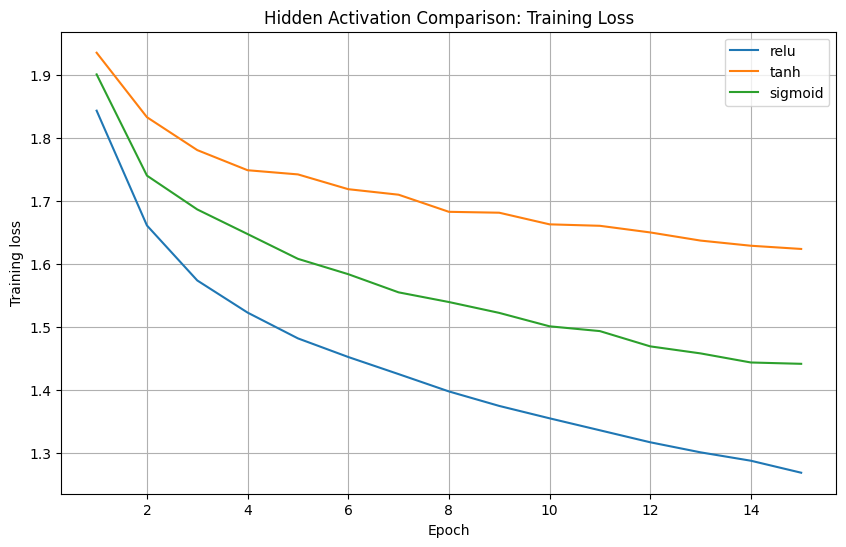

In [50]:
if results:
    plt.figure(figsize=(10, 6))
    for result in results:
        if result["name"].startswith("fixed_256_128"):
            hist = pd.DataFrame(result["history"])
            plt.plot(hist["epoch"], hist["train_loss"], label=result["config"]["activation"])
    plt.title("Hidden Activation Comparison: Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.legend()
    plt.grid(True)
    plt.show()


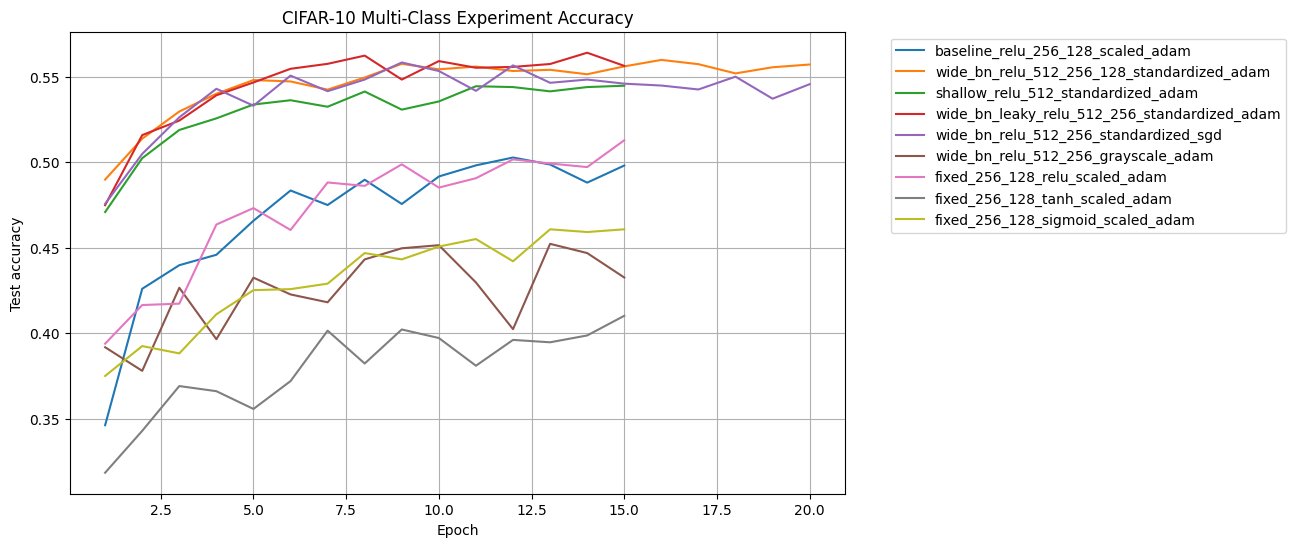

In [51]:
if results:
    plt.figure(figsize=(10, 6))
    for result in results:
        hist = pd.DataFrame(result["history"])
        plt.plot(hist["epoch"], hist["test_accuracy"], label=result["name"])
    plt.title("CIFAR-10 Multi-Class Experiment Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Test accuracy")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()


#### Findings and Conclusions

**Input/output and last-layer design:**

- The standard flattened RGB CIFAR-10 MLP input has `3072` input neurons because each image is `32 * 32 * 3`.
- A grayscale preprocessing experiment changes the MLP input size to `1024`, but all RGB MLP experiments use `3072`.
- The fully connected model must have `10` output neurons for the 10 CIFAR-10 classes.
- The final layer should return raw logits, with no `Softmax`, when using `nn.CrossEntropyLoss`. This loss applies `LogSoftmax` internally, so adding `Softmax` before it is unnecessary and can make optimization numerically worse.
- The train function keeps the same forward/loss/backward/optimizer-step structure used in the binary task. The important multi-class changes are the loss function, output shape, and label dtype.

**Exact MLP run results:**

- Best MLP sweep result: `wide_bn_leaky_relu_512_256_standardized_adam` reached `0.5641` test accuracy at epoch `14`, with best test loss `1.401919`. This is the strongest saved MLP experiment and passes the `>0.53` target.
- `wide_bn_relu_512_256_128_standardized_adam` was close, reaching `0.5599` test accuracy at epoch `16`, with best test loss `1.562630`.
- `wide_bn_relu_512_256_standardized_sgd` reached `0.5584` test accuracy at epoch `9`, with best test loss `1.326918`.
- `shallow_relu_512_standardized_adam` reached `0.5448` test accuracy at epoch `15`, so even one hidden layer can pass the target if it is wide enough and standardized.
- The smaller scaled-pixel baseline `baseline_relu_256_128_scaled_adam` reached only `0.5028` test accuracy at epoch `12`; the matching activation-control ReLU run reached `0.5129` at epoch `15`.
- Grayscale preprocessing reduced input size from `3072` to `1024`, but hurt accuracy: `wide_bn_relu_512_256_grayscale_adam` peaked at `0.4523` test accuracy at epoch `13`.

**Depth and width:**

- The best executed MLP size in this sweep is a medium MLP: `3072 -> 512 -> 256 -> 10` with BatchNorm, LeakyReLU hidden layers, standardized RGB inputs, Adam, and raw-logit output.
- The task does not require a very deep fully connected model to cross `0.53`: the one-hidden-layer `3072 -> 512 -> 10` model reached `0.5448`. However, adding more width and a second hidden layer improved the best MLP accuracy from `0.5448` to `0.5641`.
- The three-hidden-layer ReLU model also passed the target with `0.5599`, but it did not beat the two-hidden-layer LeakyReLU run in the saved results.

**Hyperparameters:**

- Adam was the easiest optimizer to tune in the executed MLP run. The best Adam MLP reached `0.5641` test accuracy at epoch `14`.
- SGD with momentum was competitive: it reached `0.5584` at epoch `9`, but it did not beat the best Adam run.
- BatchNorm plus standardized RGB inputs mattered more than just training the smaller scaled baseline longer: the scaled `256 -> 128` baseline stayed around `0.5028`, while standardized wider MLPs reached `0.5448` to `0.5641`.

**Activations:**

- In the fixed `256 -> 128` activation comparison, ReLU was best: `0.5129` test accuracy at epoch `15`.
- Sigmoid was weaker: `0.4608` test accuracy at epoch `13`.
- Tanh was weakest in this run: `0.4102` test accuracy at epoch `15`.
- In the wider standardized models, LeakyReLU slightly beat ReLU in the saved run: `0.5641` for LeakyReLU versus `0.5599` for the three-hidden-layer ReLU model.

**Preprocessing:**

- Scaling pixels to `[0, 1]` is a useful minimum, but it was not enough for the smaller baseline MLP to solve the task successfully in this sweep.
- Per-channel standardization was beneficial for the stronger MLP models, likely because the inputs were centered and scaled before the layers.
- Grayscale reduced compute and input dimension, but it discarded useful color information; the exact peak accuracy, `0.4523`, was far below the RGB standardized MLP models.

**Overall conclusion:**

For a fully connected CIFAR-10 classifier on flattened pixels, the most reasonable executed MLP from this sweep is `3072 -> 512 -> 256 -> 10` with BatchNorm, LeakyReLU hidden activations, standardized RGB inputs, Adam, and raw logits for `nn.CrossEntropyLoss`. The best observed checkpoint is epoch `14`, where this MLP clears the `0.53` target with `0.5641` test accuracy. The CNN experiment and spatial-architecture comparison live in `homework_CIFAR10_bonus_3_CNN.ipynb`.


That's it for the tasks in this notebook!
